In [33]:
import pandas as pd

In [31]:
supply = [
    (1, 15, 75),
    (2, 102, 20),
    (3, 32, 0),
    (4, 25, 42),
    (5, 68, 15),
    (6, 23, 75),
    (7, 120, 17),
    (8, 35, 40),
    (9, 50, 0),
    (10, 65, 12),
]
supply = pd.DataFrame(supply, columns=['num', 'capacity', 'price'])
supply['name'] = supply['num'].map(lambda s: f"G{s}")
supply = supply.set_index('name')
def region(i):
    return "EMRB" if i <= 5 else "EMDD"
supply['region'] = supply['num'].map(region)

In [32]:
supply

,num,capacity,price,region
name,,,,
G1,1,15,75,EMRB
G2,2,102,20,EMRB
G3,3,32,0,EMRB
G4,4,25,42,EMRB
G5,5,68,15,EMRB
G6,6,23,75,EMDD
G7,7,120,17,EMDD
G8,8,35,40,EMDD
G9,9,50,0,EMDD


In [95]:
demand = [
    (1, 35, 65),
    (2, 23, 78),
    (3, 12, 10),
    (4, 38, 46),
    (5, 43, 64),
    (6, 17, 32),
    (7, 56, 50),
    (8, 48, 72),
    (9, 62, 80),
    (10, 15, 10),
    (11, 50, 42),
    (12, 48, 64),
    (13, 18, 32),
    (14, 30, 48),
]
demand = pd.DataFrame(demand, columns=['num', 'capacity', 'price'])
demand['name'] = demand['num'].map(lambda s: f"D{s}")
demand = demand.set_index('name')
def region(i):
    return "EMRB" if i <= 7 else "EMDD"
demand['region'] = demand['num'].map(region)

In [96]:
demand

,num,capacity,price,region
name,,,,
D1,1,35,65,EMRB
D2,2,23,78,EMRB
D3,3,12,10,EMRB
D4,4,38,46,EMRB
D5,5,43,64,EMRB
D6,6,17,32,EMRB
D7,7,56,50,EMRB
D8,8,48,72,EMDD
D9,9,62,80,EMDD


In [38]:
import matplotlib.pyplot as plt

In [45]:
import numpy as np

In [64]:
from pathlib import Path

In [65]:
DATA_DIR = Path("/Users/sean/code/study-hard/power-systems-ops/latex/hw1/Images")

In [71]:
demand_forecast = {
    "EMRB": 190,
    "EMDD": 235
}

In [80]:
def cap_curve(cap, price):
    cap_out = []
    price_out = []
    cum = np.r_[0, np.cumsum(cap)]
    for c1, c2, p in zip(cum[:-1], cum[1:], price):
        cap_out.extend([c1, c2])
        price_out.extend([p, p])
    return cap_out, price_out
    

In [98]:
sup['price'].argmax()

np.int64(4)

In [99]:
np.argmax(sup['price'])

np.int64(4)

In [134]:
def plot_cumulative_curve(df, label, extra_offset=False):
    cap, price = cap_curve(df['capacity'], df['price'])
    plt.plot(cap, price, label=label)
    
    # Annotate the names of supply / generation
    for i, (c, p, n) in enumerate(zip(df['cumsum'], df['price'], df.index)):
        if i == np.argmax(df['price']):
            print('argmax:', np.argmax(df['price']))
            y_offset = 0
        else:
            y_offset = 10
        if label == 'Demand':
            y_offset *= -1
        # x_offset = -20 if label == "Supply" else 20
        x_offset = -20
        if extra_offset and n in ['D13', 'D10']:
            y_offset -= 10
        plt.annotate(n, (c, p),
             textcoords="offset points", xytext=(x_offset,y_offset), ha='center',
             arrowprops=dict(arrowstyle="->", color='black'))

EMRB
      num  capacity  price region  cumsum
name                                     
G3      3        32      0   EMRB      32
G5      5        68     15   EMRB     100
G2      2       102     20   EMRB     202
G4      4        25     42   EMRB     227
G1      1        15     75   EMRB     242
argmax: 4
EMDD
      num  capacity  price region  cumsum
name                                     
G9      9        50      0   EMDD      50
G10    10        65     12   EMDD     115
G7      7       120     17   EMDD     235
G8      8        35     40   EMDD     270
G6      6        23     75   EMDD     293
argmax: 4


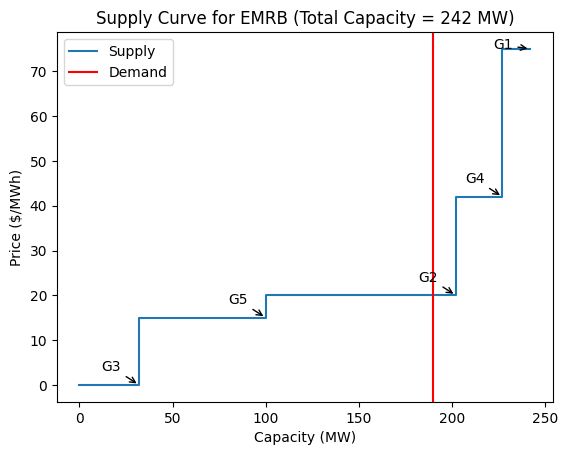

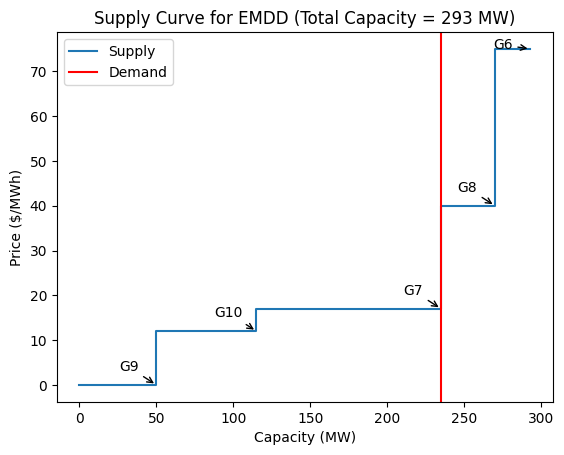

In [114]:
for region in pd.unique(supply['region']):
    print(region)
    sup = supply[supply['region'] == region].sort_values(by='price')
    sup['cumsum'] = sup['capacity'].cumsum()
    
    print(sup)
    total = sup['capacity'].sum()
    
    fig = plt.figure()
    
    plt.xlabel("Capacity (MW)")
    plt.ylabel("Price ($/MWh)")
    plt.title(f"Supply Curve for {region} (Total Capacity = {total} MW)")

    plot_cumulative_curve(sup, 'Supply')

    # Plot demand
    d_f = demand_forecast[region]
    plt.axvline(x=d_f, c='r', label='Demand')
    
    plt.legend()
    fig.savefig(DATA_DIR / f"supply_{region}.png")
    
    
    

In [88]:
sup = supply[supply['region'] == 'EMRB']
sup = sup.sort_values(by='price')

energy = np.array([32, 68, 90, 0, 0])
price = 20
rev = energy * price
profit = energy * (price - sup['price'])
print(rev)
print(profit)


    

[ 640 1360 1800    0    0]
name
G3    640
G5    340
G2      0
G4      0
G1      0
Name: price, dtype: int64


In [89]:
sup = supply[supply['region'] == 'EMDD']
sup = sup.sort_values(by='price')

energy = np.array([50, 65, 120, 0, 0])
price = 40
rev = energy * price
profit = energy * (price - sup['price'])
print(rev)
print(profit)


    

[2000 2600 4800    0    0]
name
G9     2000
G10    1820
G7     2760
G8        0
G6        0
Name: price, dtype: int64


In [121]:
    print(dem[['price', 'capacity', 'cumsum']].rename({
        'price': "Price ($/MWh)",
        'capacity': "Demand (MWh)",
        'cumsum': 'Cumulative Demand (MWh)',
    }))

      price  capacity  cumsum
name                         
D9       80        62      62
D8       72        48     110
D12      64        48     158
D14      48        30     188
D11      42        50     238
D13      32        18     256
D10      10        15     271


EMRB
      price  capacity  cumsum
name                         
D2       78        23      23
D1       65        35      58
D5       64        43     101
D7       50        56     157
D4       46        38     195
D6       32        17     212
D3       10        12     224
argmax: 4
argmax: 0
EMDD
      price  capacity  cumsum
name                         
D9       80        62      62
D8       72        48     110
D12      64        48     158
D14      48        30     188
D11      42        50     238
D13      32        18     256
D10      10        15     271
argmax: 4
argmax: 0


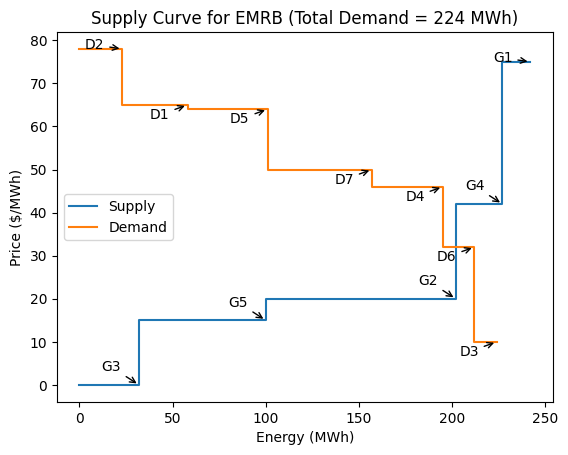

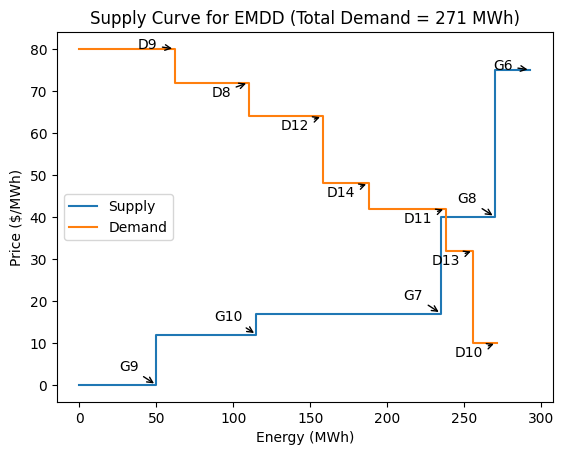

In [138]:
# Supply and demand bidding together.
for region in pd.unique(supply['region']):
    print(region)
    sup = supply[supply['region'] == region].sort_values(by='price')
    sup['cumsum'] = sup['capacity'].cumsum()
    dem = demand[demand['region'] == region].sort_values(by='price', ascending=False)
    dem['cumsum'] = dem['capacity'].cumsum()
    
    print(dem[['price', 'capacity', 'cumsum']].rename({
        'price': "Price ($/MWh)",
        'capacity': "Demand (MWh)",
        'cumsum': 'Cumulative Demand (MWh)',
    }))
    total = dem['capacity'].sum()

    
    fig = plt.figure()
    
    plt.xlabel("Energy (MWh)")
    plt.ylabel("Price ($/MWh)")
    plt.title(f"Supply Curve for {region} (Total Demand = {total} MWh)")

    plot_cumulative_curve(sup, 'Supply')
    plot_cumulative_curve(dem, 'Demand')

    plt.legend()
    fig.savefig(DATA_DIR / f"demand_{region}.png")
    
    
    

In [126]:
market_prices = {
    'EMRB': 32,
    'EMDD': 40
}
energy_gen = {
    'EMRB': [32, 68, 102, 0, 0],
    'EMDD': [50, 65, 120, 3, 0]
}
energy_con = {
    'EMRB': [23, 35, 43, 56, 38, 7, 0],
    'EMDD': [62, 48, 48, 30, 50, 0, 0]
}

In [127]:
for region in pd.unique(supply['region']):
    print(region)
    sup = supply[supply['region'] == region].sort_values(by='price')
    
    p = market_prices[region]
    gen = np.array(energy_gen[region])
    sup['gen'] = gen
    sup['rev'] = gen * p
    sup['profit'] = gen * (p - sup['price'])
    print(sup[['gen', 'rev', 'profit']])
    
    dem = demand[demand['region'] == region].sort_values(by='price', ascending=False)
    dem['cumsum'] = dem['capacity'].cumsum()
    con = np.array(energy_con[region])
    dem['con'] = con
    dem['cost'] = p * con
    
    
    print(dem[['con', 'cost']])
                        
    

EMRB
      gen   rev  profit
name                   
G3     32  1024    1024
G5     68  2176    1156
G2    102  3264    1224
G4      0     0       0
G1      0     0       0
      con  cost
name           
D2     23   736
D1     35  1120
D5     43  1376
D7     56  1792
D4     38  1216
D6      7   224
D3      0     0
EMDD
      gen   rev  profit
name                   
G9     50  2000    2000
G10    65  2600    1820
G7    120  4800    2760
G8      3   120       0
G6      0     0       0
      con  cost
name           
D9     62  2480
D8     48  1920
D12    48  1920
D14    30  1200
D11    50  2000
D13     0     0
D10     0     0


In [29]:
supply

,num,capacity,price,name
0,1,15,75,G1
1,2,102,20,G2
2,3,32,0,G3
3,4,25,42,G4
4,5,68,15,G5
5,6,23,75,G6
6,7,120,17,G7
7,8,35,40,G8
8,9,50,0,G9
9,10,65,12,G10


In [28]:
demand


,num,capacity,price
name,,,
D1,1,35,65
D2,2,23,78
D3,3,12,10
D4,4,38,46
D5,5,43,64
D6,6,17,32
D7,7,56,50
D8,8,48,72
D9,9,62,80


In [13]:
supply

,quantity,price,name
name,,,
1,15,75,D1
2,102,20,D2
3,32,0,D3
4,25,42,D4
5,68,15,D5
6,23,75,D6
7,120,17,D7
8,35,40,D8
9,50,0,D9


In [40]:
help(supply['capacity'].cumsum)

Help on method cumsum in module pandas.core.series:

cumsum(axis: 'Axis | None' = None, skipna: 'bool' = True, *args, **kwargs) method of pandas.core.series.Series instance
    Return cumulative sum over a DataFrame or Series axis.

    Returns a DataFrame or Series of the same size containing the cumulative
    sum.

    Parameters
    ----------
    axis : {0 or 'index', 1 or 'columns'}, default 0
        The index or the name of the axis. 0 is equivalent to None or 'index'.
        For `Series` this parameter is unused and defaults to 0.
    skipna : bool, default True
        Exclude NA/null values. If an entire row/column is NA, the result
        will be NA.
    *args, **kwargs
        Additional keywords have no effect but might be accepted for
        compatibility with NumPy.

    Returns
    -------
    scalar or Series
        Return cumulative sum of scalar or Series.

    See Also
    --------
    core.window.expanding.Expanding.sum : Similar functionality
        but igno

      num  capacity  price region  cumsum
name                                     
G3      3        32      0   EMRB      32
G9      9        50      0   EMDD      82
G10    10        65     12   EMDD     147
G5      5        68     15   EMRB     215
G7      7       120     17   EMDD     335
G2      2       102     20   EMRB     437
G8      8        35     40   EMDD     472
G4      4        25     42   EMRB     497
G1      1        15     75   EMRB     512
G6      6        23     75   EMDD     535
      num  capacity  price region  cumsum
name                                     
D9      9        62     80   EMDD      62
D2      2        23     78   EMRB      85
D8      8        48     72   EMDD     133
D1      1        35     65   EMRB     168
D5      5        43     64   EMRB     211
D12    12        48     64   EMDD     259
D7      7        56     50   EMRB     315
D14    14        30     48   EMDD     345
D4      4        38     46   EMRB     383
D11    11        50     42   EMDD 

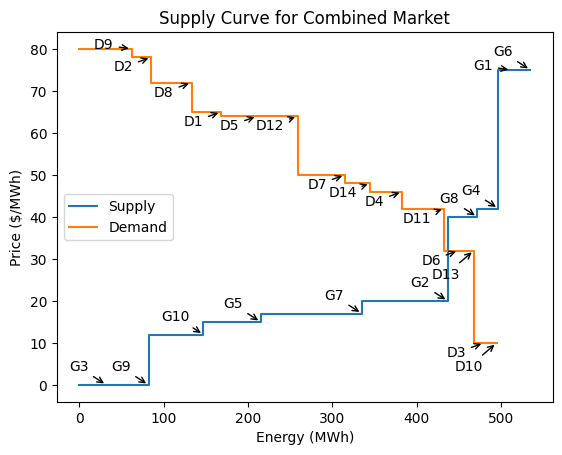

In [139]:
# Both regions combined
# sup = supply[supply['region'] == region].sort_values(by='price')
# sup['cumsum'] = sup['capacity'].cumsum()
# dem = demand[demand['region'] == region].sort_values(by='price', ascending=False)
# dem['cumsum'] = dem['capacity'].cumsum()
# 
# print(dem[['price', 'capacity', 'cumsum']].rename({
#     'price': "Price ($/MWh)",
#     'capacity': "Demand (MWh)",
#     'cumsum': 'Cumulative Demand (MWh)',
# }))
# total = dem['capacity'].sum()

supply = supply.sort_values(by='price')
demand = demand.sort_values(by='price', ascending=False)
supply['cumsum'] = supply['capacity'].cumsum()
demand['cumsum'] = demand['capacity'].cumsum()
print(supply)
print(demand)

fig = plt.figure()

plt.xlabel("Energy (MWh)")
plt.ylabel("Price ($/MWh)")
plt.title(f"Supply Curve for Combined Market")

plot_cumulative_curve(supply, 'Supply')
plot_cumulative_curve(demand, 'Demand', extra_offset=True)

plt.legend()
fig.savefig(DATA_DIR / f"demand_total.png")


